<a href="https://colab.research.google.com/github/thcen-dev/ai-health-data-project/blob/midHeap/Assignment_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [64]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


Here we import the DMERC spreadsheet to begin analysis. The first step is to get an idea of its shape, or the amount of values that we will be working with. to do so, we will be using " df.shape " which returns to us (rows, columns) from the spreadsheet. We will also call " df " to peek at the first and last five rows of the spread sheet to get a feel for what we will be working with.

In [65]:
df = pd.read_excel("/content/DMERC_VersionK2016_20250408 (2).xlsx")

df.shape

(121, 9)

In [66]:
df

,No.,Field Short Name,Field Long Name,Label,Type,Length,URL,Display Name,File Name
0,DMERC Base Claim File,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,DSYSRTKY,DESY_SORT_KEY,LDS Beneficiary ID,NUM,9.0,NaN,NaN,NaN
2,2,CLAIMNO,CLAIM_NO,Claim number,NUM,12.0,NaN,NaN,NaN
3,3,THRU_DT,CLM_THRU_DT,Claim Through Date (Determines Year of Claim),DATE,8.0,NaN,THRU_DT,THRU_DT
4,4,RIC_CD,NCH_NEAR_LINE_REC_IDENT_CD,NCH Near Line Record Identification Code,CHAR,1.0,NaN,WKLY_DT,WKLY_DT
...,...,...,...,...,...,...,...,...,...
116,3,DEMO_ID_SQNC_NUM,DEMO_ID_SQNC_NUM,Claim Demonstration Sequence,NUM,3.0,3.0,NaN,NaN
117,4,THRU_DT,CLM_THRU_DT,Claim Through Date (Determines Year of Claim),DATE,8.0,8.0,NaN,NaN
118,5,CLM_TYPE,NCH_CLM_TYPE_CD,NCH Claim Type Code,CHAR,2.0,2.0,NaN,NaN
119,6,DEMO_ID_NUM,DEMO_ID_NUM,Claim Demonstration Identification Number,CHAR,2.0,2.0,NaN,NaN


Now that we have a little feel for what our data has to offer, we can begin to look at what our spreadsheet has and what it does not have. To do that, we will call " df.info " to analyze the missing and filled spaces for each of the (121, 9) values in the spreadsheet. To confirm the number of missing spaces we will also call " df.isnull().sum() " to get a value for how many items are missing.

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   No.               119 non-null    object 
 1   Field Short Name  116 non-null    object 
 2   Field Long Name   116 non-null    object 
 3   Label             116 non-null    object 
 4   Type              116 non-null    object 
 5   Length            116 non-null    float64
 6   URL               7 non-null      float64
 7   Display Name      53 non-null     object 
 8   File Name         53 non-null     object 
dtypes: float64(2), object(7)
memory usage: 8.6+ KB


In [68]:
df.isnull().sum()

,0
No.,2
Field Short Name,5
Field Long Name,5
Label,5
Type,5
Length,5
URL,114
Display Name,68
File Name,68


We will now call " df.describe(percentiles=[], include='object').T " to give us a broader analysis of the data, as it tells us the frequency, top user, ect.

In [69]:
df.describe(percentiles=[], include='object').T

,count,unique,top,freq
No.,119,60,1,3
Field Short Name,116,108,DSYSRTKY,3
Field Long Name,116,108,DESY_SORT_KEY,3
Label,116,109,LDS Beneficiary ID,3
Type,116,3,CHAR,75
Display Name,53,50,THRU_DT,2
File Name,53,50,THRU_DT,2


In [70]:
df.describe([]).T

,count,mean,std,min,50%,max
Length,116.0,6.077586,4.581913,1.0,6.0,15.0
URL,7.0,7.285714,5.154748,2.0,8.0,15.0


Using the call " msno.bar(df) " from our 'missingno' library, we are able to get a visualization for what our data has and what it is missing. After running the code below, you can see that 'URL' 'Display

<Axes: >

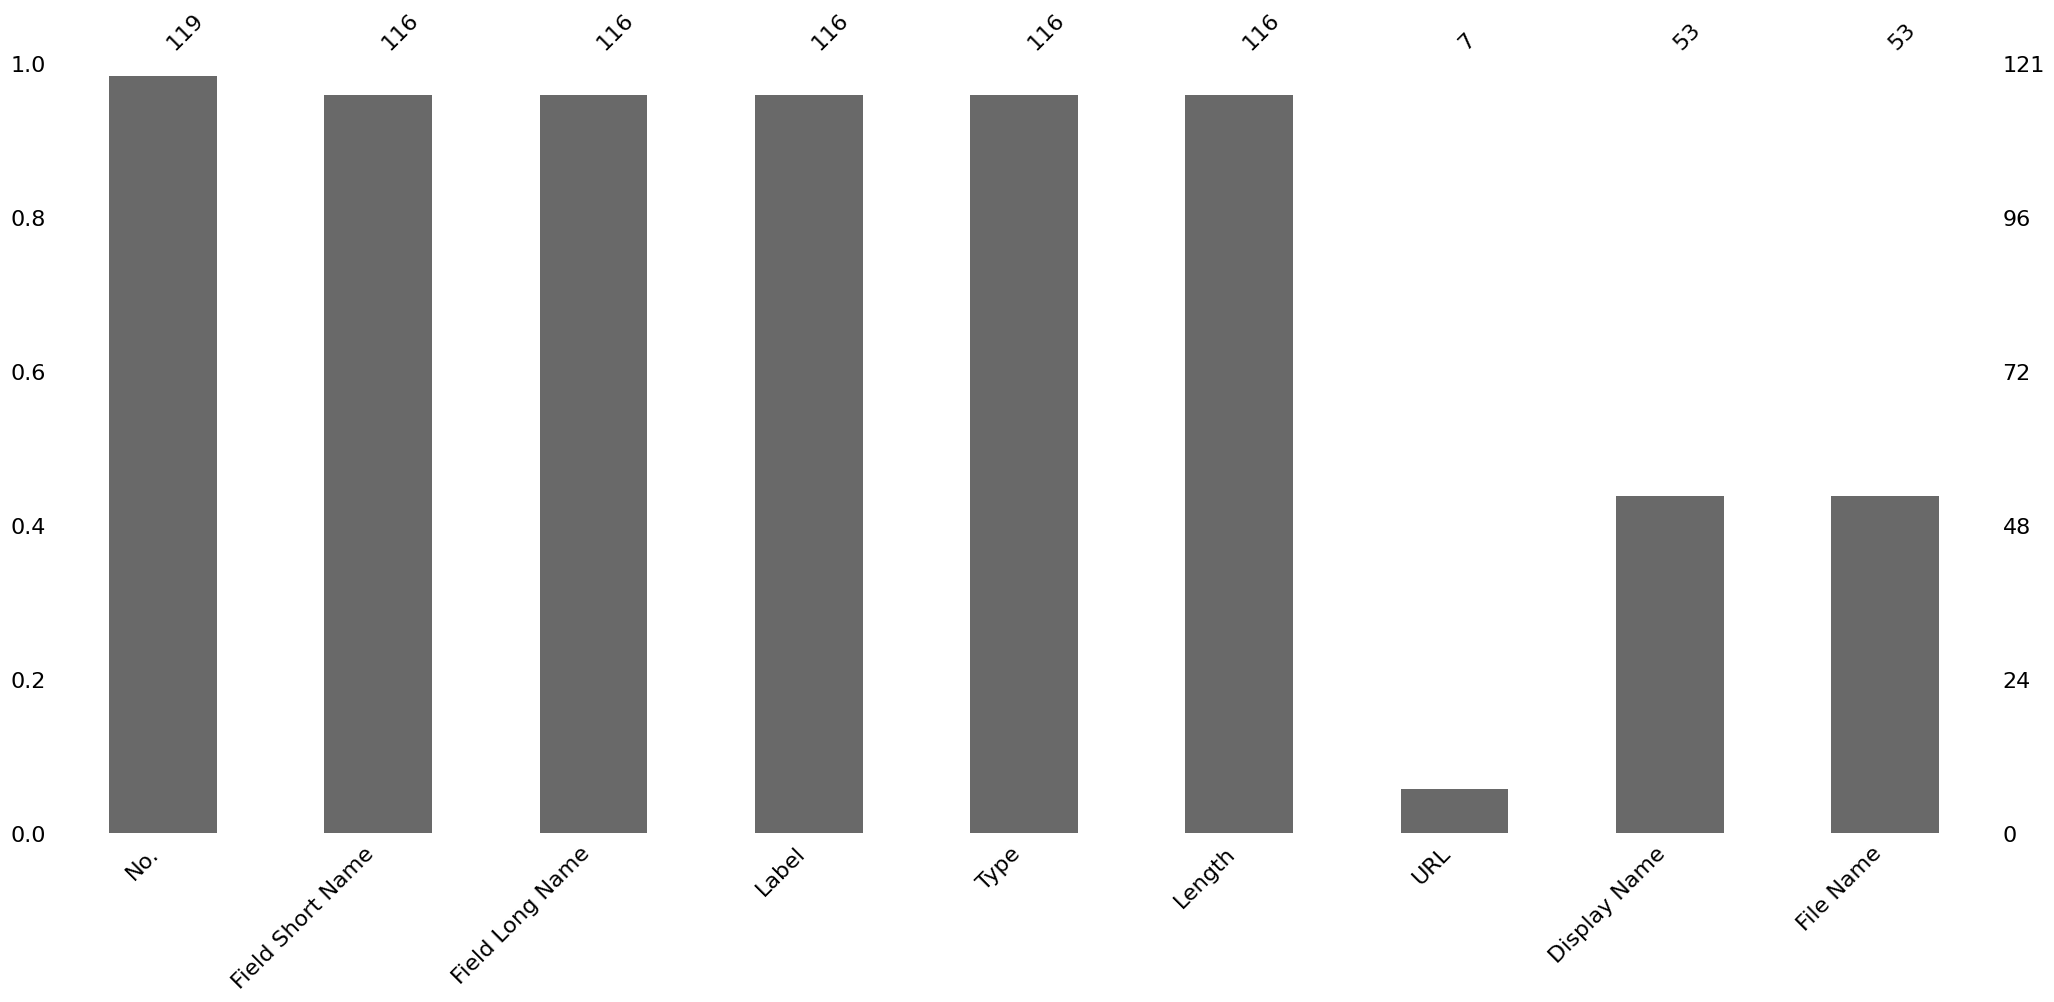

In [71]:
msno.bar(df)

For the

In [72]:
df['Display Name'] = df['Display Name'].fillna(df['Field Short Name'])

In [73]:
df['File Name'] = df['File Name'].fillna(df['Display Name'])

In [74]:
df['File Name'] = df['File Name'].str.replace(" ", "_").str.lower()

Below shows that it worked.

In [75]:
df[['Display Name', 'File Name']].isnull().sum()

,0
Display Name,5
File Name,5


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   No.               119 non-null    object 
 1   Field Short Name  116 non-null    object 
 2   Field Long Name   116 non-null    object 
 3   Label             116 non-null    object 
 4   Type              116 non-null    object 
 5   Length            116 non-null    float64
 6   URL               7 non-null      float64
 7   Display Name      116 non-null    object 
 8   File Name         116 non-null    object 
dtypes: float64(2), object(7)
memory usage: 8.6+ KB


In [77]:
df

,No.,Field Short Name,Field Long Name,Label,Type,Length,URL,Display Name,File Name
0,DMERC Base Claim File,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,DSYSRTKY,DESY_SORT_KEY,LDS Beneficiary ID,NUM,9.0,NaN,DSYSRTKY,dsysrtky
2,2,CLAIMNO,CLAIM_NO,Claim number,NUM,12.0,NaN,CLAIMNO,claimno
3,3,THRU_DT,CLM_THRU_DT,Claim Through Date (Determines Year of Claim),DATE,8.0,NaN,THRU_DT,thru_dt
4,4,RIC_CD,NCH_NEAR_LINE_REC_IDENT_CD,NCH Near Line Record Identification Code,CHAR,1.0,NaN,WKLY_DT,wkly_dt
...,...,...,...,...,...,...,...,...,...
116,3,DEMO_ID_SQNC_NUM,DEMO_ID_SQNC_NUM,Claim Demonstration Sequence,NUM,3.0,3.0,DEMO_ID_SQNC_NUM,demo_id_sqnc_num
117,4,THRU_DT,CLM_THRU_DT,Claim Through Date (Determines Year of Claim),DATE,8.0,8.0,THRU_DT,thru_dt
118,5,CLM_TYPE,NCH_CLM_TYPE_CD,NCH Claim Type Code,CHAR,2.0,2.0,CLM_TYPE,clm_type
119,6,DEMO_ID_NUM,DEMO_ID_NUM,Claim Demonstration Identification Number,CHAR,2.0,2.0,DEMO_ID_NUM,demo_id_num


<Axes: >

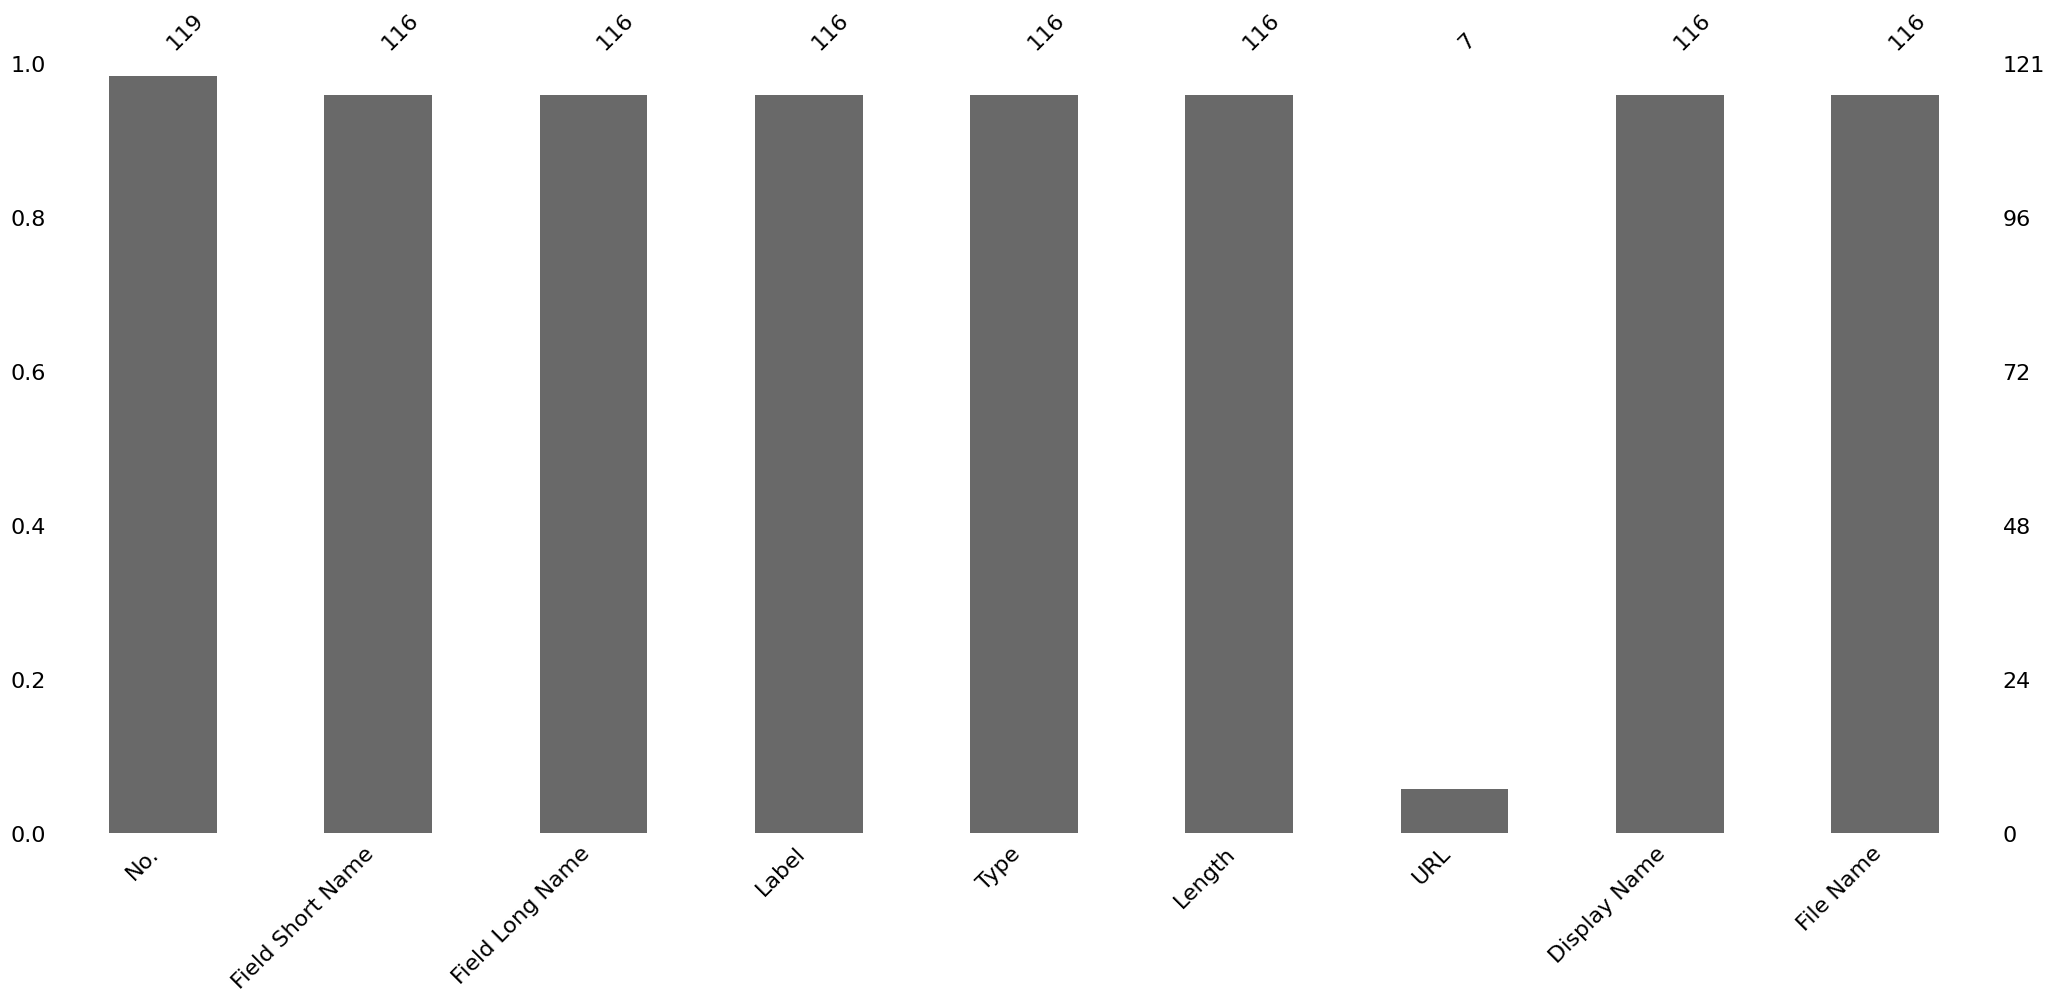

In [78]:
msno.bar(df)

In [79]:
df_cleaned = df.drop(columns=['URL'])

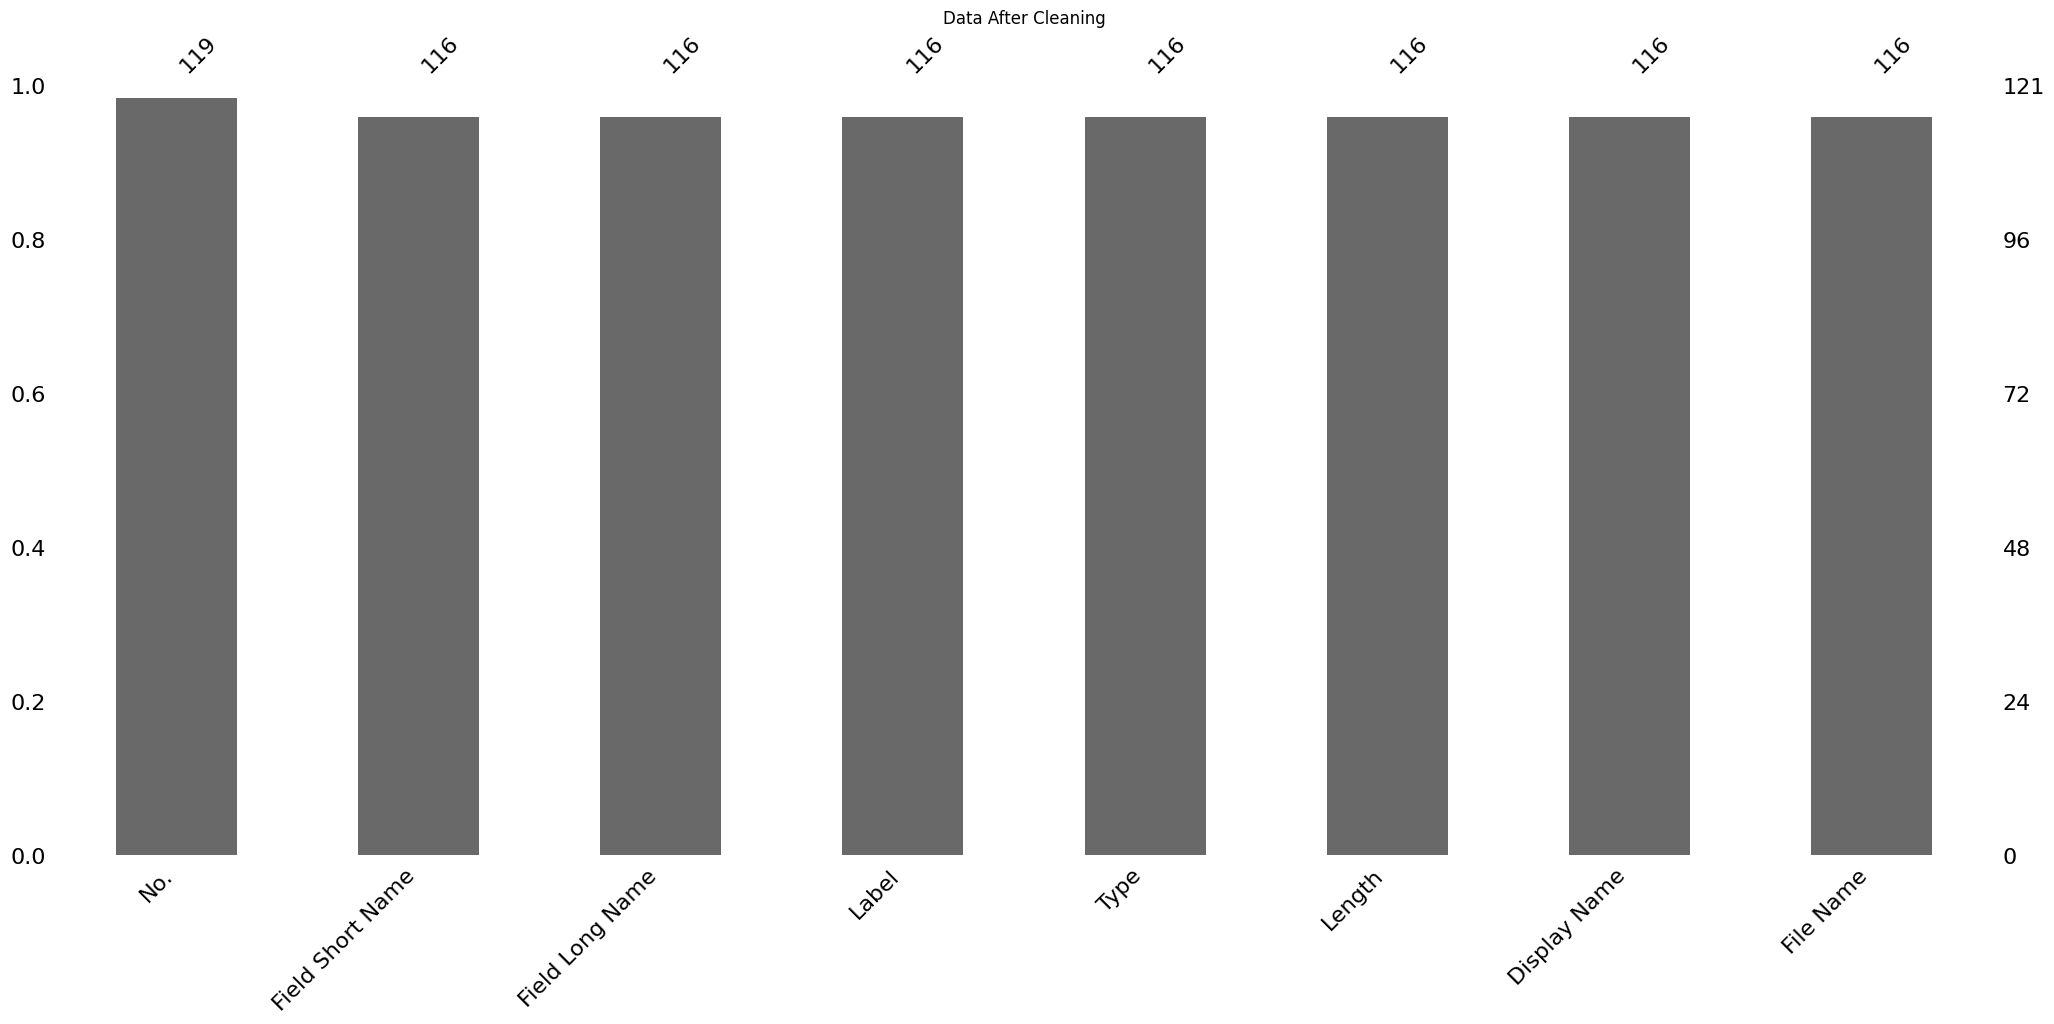

In [80]:
msno.bar(df_cleaned)
plt.title("Data After Cleaning")
plt.show()

In [81]:
df.to_csv('DataEngineeredSet.csv', index=False)

In [82]:
df_check = pd.read_csv('DataEngineeredSet.csv')
df_check.head(10)

,No.,Field Short Name,Field Long Name,Label,Type,Length,URL,Display Name,File Name
0,DMERC Base Claim File,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,DSYSRTKY,DESY_SORT_KEY,LDS Beneficiary ID,NUM,9.0,NaN,DSYSRTKY,dsysrtky
2,2,CLAIMNO,CLAIM_NO,Claim number,NUM,12.0,NaN,CLAIMNO,claimno
3,3,THRU_DT,CLM_THRU_DT,Claim Through Date (Determines Year of Claim),DATE,8.0,NaN,THRU_DT,thru_dt
4,4,RIC_CD,NCH_NEAR_LINE_REC_IDENT_CD,NCH Near Line Record Identification Code,CHAR,1.0,NaN,WKLY_DT,wkly_dt
5,5,CLM_TYPE,NCH_CLM_TYPE_CD,NCH Claim Type Code,CHAR,2.0,NaN,FI_CLM_PROC_DT,fi_clm_proc_dt
6,6,DISP_CD,CLM_DISP_CD,Claim Disposition Code,CHAR,2.0,NaN,FAC_TYPE,fac_type
7,7,CARR_NUM,CARR_NUM,Carrier Number,CHAR,5.0,NaN,TYPESRVC,typesrvc
8,8,PMTDNLCD,CARR_CLM_PMT_DNL_CD,Carrier Claim Payment Denial Code,CHAR,2.0,NaN,FREQ_CD,freq_cd
9,9,PMT_AMT,CLM_PMT_AMT,Claim Payment Amount,NUM,12.0,NaN,PMT_AMT,pmt_amt
